In [2]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

In [4]:
df = pd.read_csv("/content/dataset_for_CC50_962.csv")
df.head(10)

,"CC50, mM",MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,175.482382,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,...,0,0,0,0,0,0,0,0,3,0
1,5.402819,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,...,0,0,0,0,0,0,0,0,3,0
2,161.142320,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,...,0,0,0,0,0,0,0,0,3,0
3,107.855654,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,...,0,0,0,0,0,0,0,0,4,0
4,139.270991,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,...,0,0,0,0,0,0,0,0,0,0
5,30.075821,5.758408,5.758408,0.278083,0.278083,0.711012,28.600000,332.491,304.267,332.225249,...,0,0,0,0,0,0,0,0,0,0
6,14.559288,2.584472,2.584472,0.429649,0.429649,0.328539,36.564103,528.869,472.421,528.443253,...,0,0,0,0,0,0,0,0,0,0
7,23.593931,13.821880,13.821880,0.079845,-0.301260,0.217332,31.333333,695.089,624.529,694.543729,...,0,0,0,0,0,0,0,0,4,0
8,153.709268,14.171614,14.171614,0.019123,-0.411828,0.187781,29.157895,763.123,696.595,762.512429,...,0,0,0,0,0,0,0,0,0,0
9,400.906360,6.135893,6.135893,0.239226,0.239226,0.439915,36.400000,468.685,428.365,468.314064,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Разделение на признаки и целевую переменную
X = df.drop('CC50, mM', axis=1)
y = df['CC50, mM']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
#Вычисляем медиану и сразу переведем в бинарные значения
median_cc50 = y_train.median()
y_train_binary = (y_train > median_cc50).astype(int)
y_test_binary = (y_test > median_cc50).astype(int)

In [12]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc= scaler.transform(X_test)

Напишем функция для обучения и оценки модели

In [16]:
def evaluate_classifiers(models, X_train, y_train, X_test, y_test):
    results = []

    for name, model in models.items():
        # Обучение с кросс-валидацией
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        acc_cv = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv).mean()
        prec_cv = cross_val_score(model, X_train, y_train, scoring='precision', cv=cv).mean()
        rec_cv = cross_val_score(model, X_train, y_train, scoring='recall', cv=cv).mean()
        f1_cv = cross_val_score(model, X_train, y_train, scoring='f1', cv=cv).mean()

        # Точность на тесте
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc_test = accuracy_score(y_test, y_pred)
        prec_test = precision_score(y_test, y_pred)
        rec_test = recall_score(y_test, y_pred)
        f1_test = f1_score(y_test, y_pred)

        results.append({
            'Model': name,
            'CV Accuracy': acc_cv,
            'CV Precision': prec_cv,
            'CV Recall': rec_cv,
            'CV F1': f1_cv,
            'Test Accuracy': acc_test,
            'Test Precision': prec_test,
            'Test Recall': rec_test,
            'Test F1': f1_test
        })

    return results

In [17]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=200, verbose=0)
}

In [18]:
results = evaluate_classifiers(models, X_train_sc, y_train_binary, X_test_sc, y_test_binary)
results_df = pd.DataFrame(results)
results_df.sort_values(by='Test F1', ascending=False, inplace=True)

print(results_df.round(4))

                 Model  CV Accuracy  CV Precision  CV Recall   CV F1  \
1              XGBoost       0.7555        0.7508     0.7651  0.7564   
3                  SVM       0.7593        0.7336     0.8197  0.7728   
0        Random Forest       0.7542        0.7490     0.7702  0.7576   
4             CatBoost       0.7711        0.7563     0.8017  0.7770   
2  Logistic Regression       0.7490        0.7392     0.7754  0.7554   

   Test Accuracy  Test Precision  Test Recall  Test F1  
1         0.7772          0.7579       0.7826   0.7701  
3         0.7617          0.7170       0.8261   0.7677  
0         0.7617          0.7347       0.7826   0.7579  
4         0.7513          0.7075       0.8152   0.7576  
2         0.7513          0.7200       0.7826   0.7500  


/tmp/ipython-input-944029032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(data=results_df, x='Model', y=f'Test {metric}', palette="viridis", ax=ax)
/tmp/ipython-input-944029032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(data=results_df, x='Model', y=f'Test {metric}', palette="viridis", ax=ax)
/tmp/ipython-input-944029032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(data=results_df, x='Model', y=f'Test {metric}', palette="viridis", ax=ax)
/tmp/ipython-input-944029032.py:8: FutureWarning: 

Passing `palette` 

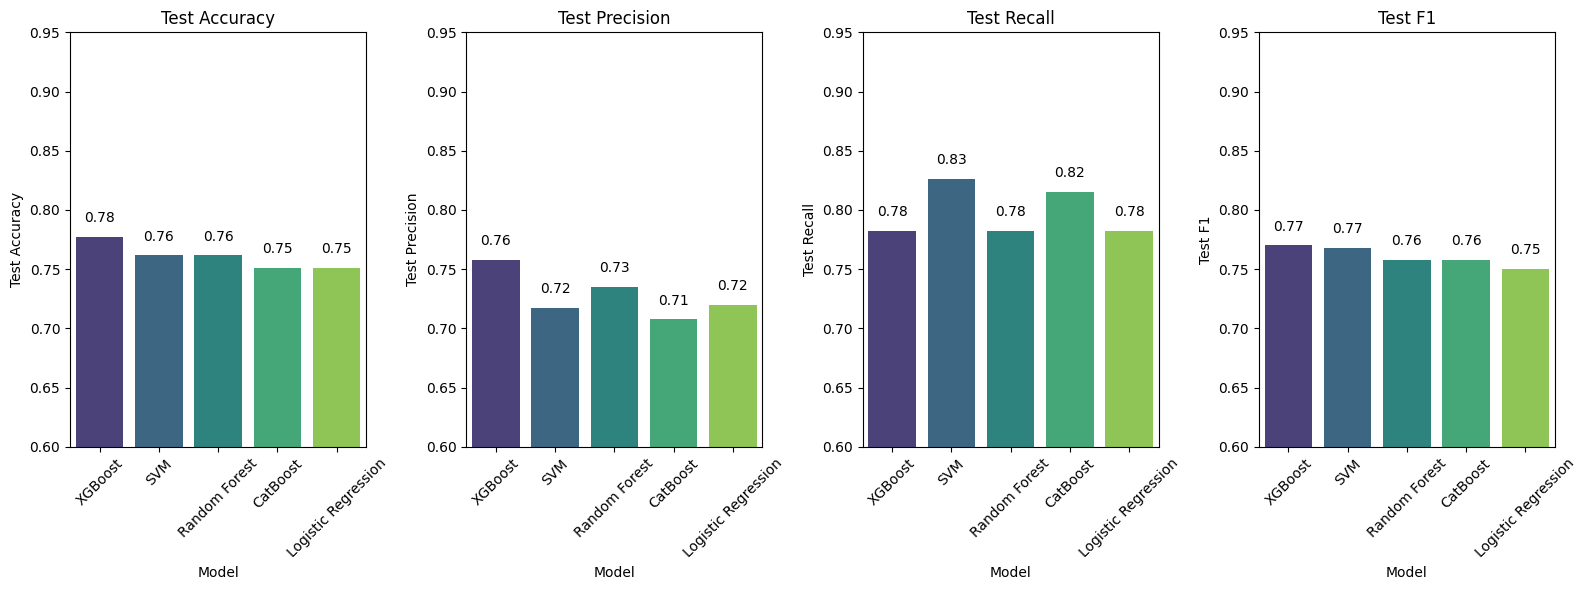

In [20]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))


for idx, metric in enumerate(metrics):
    ax = axes[idx]
    g = sns.barplot(data=results_df, x='Model', y=f'Test {metric}', palette="viridis", ax=ax)
    ax.set_ylim(0.6, 0.95)
    ax.tick_params(axis='x', rotation=45)

    for patch in g.patches:
        height = patch.get_height()
        g.annotate(f'{height:.2f}',
                  xy=(patch.get_x() + patch.get_width() / 2, height + 0.01),
                  ha='center', va='bottom', fontsize=10)

    ax.set_title(f'Test {metric}')


plt.tight_layout()
plt.show()

XGBoost показала лучший результат суммарно по всем метрикам, поработаем с ней дальше

In [25]:
# Параметры для подбора
param_grid = {
    'n_estimators': [100, 150, 200, 250],
    'criterion': ["gini", "entropy", "log_loss"],
    'max_depth': [None, 10, 20, 30],
}

# Инициализация XGB
xgb_model = XGBClassifier(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(xgb_model, param_grid, cv=10, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train_sc, y_train_binary)

# Лучшая модель
best_xgb = grid_search.best_estimator_
print("Лучшие параметры:", grid_search.best_params_)

Fitting 10 folds for each of 48 candidates, totalling 480 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [18:50:19] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "criterion" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Лучшие параметры: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 150}


In [26]:
y_pred = best_xgb.predict(X_test_sc)
acc_test = accuracy_score(y_test_binary, y_pred)
prec_test = precision_score(y_test_binary, y_pred)
rec_test = recall_score(y_test_binary, y_pred)
f1_test = f1_score(y_test_binary, y_pred)


In [27]:
print(f'Test Accuracy: {acc_test}')
print(f'Test Precision: {prec_test}')
print(f'Test Recall: {rec_test}')
print(f'Test F1: {f1_test}')
results.append({
    'Model': 'Random Forest tuned',
    'CV Accuracy': None,
    'CV Precision': None,
    'CV Recall': None,
    'CV F1': None,
    'Test Accuracy': acc_test,
    'Test Precision': prec_test,
    'Test Recall': rec_test,
    'Test F1': f1_test
})

Test Accuracy: 0.7616580310880829
Test Precision: 0.7254901960784313
Test Recall: 0.8043478260869565
Test F1: 0.7628865979381443


Посмотрим на визуализацию

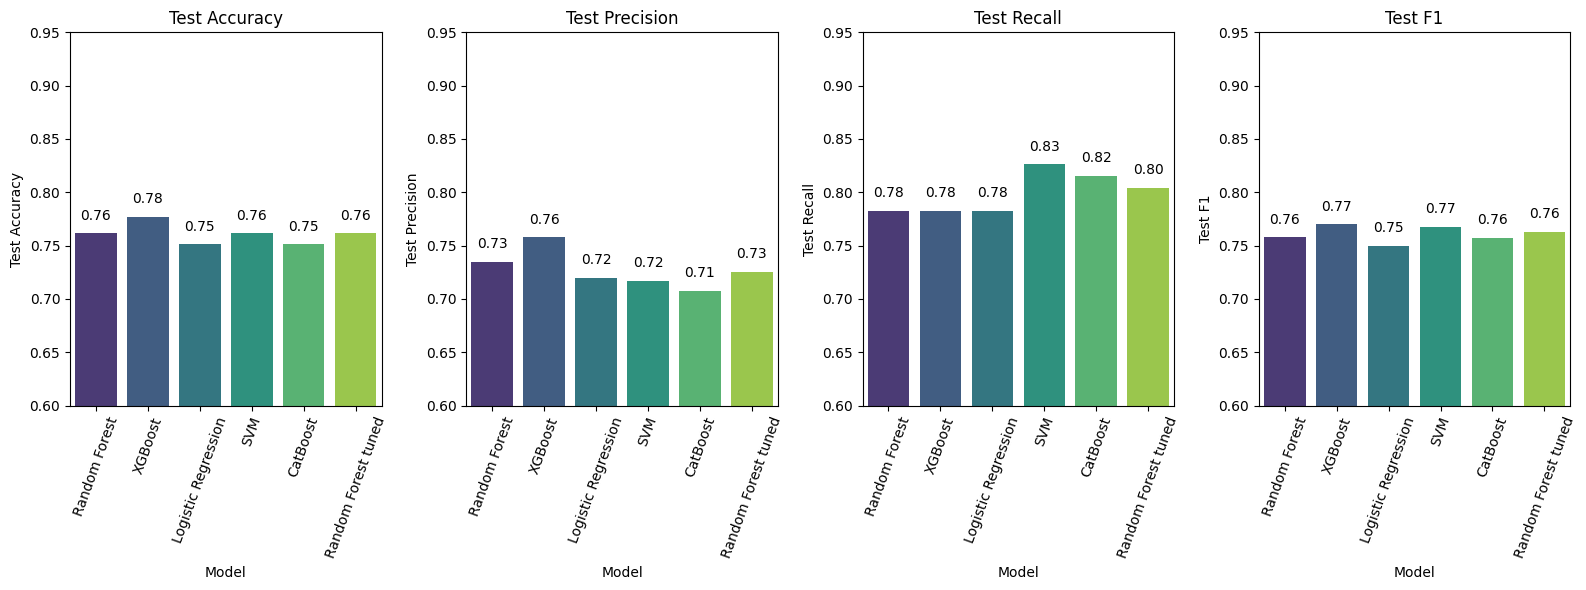

In [31]:
results_df = pd.DataFrame(results)

plt.figure(figsize=(16, 6))

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    ax = sns.barplot(x='Model', y=f'Test {metric}', data=results_df, palette="viridis", hue='Model', legend=False)
    plt.title(f'Test {metric}')
    plt.ylim(0.6, 0.95)
    plt.xticks(rotation=70)

    # Добавление подписей значений
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Результаты получились чуть получше. Попробуем подобрать порог вероятности, максимизирующий F1 у модели с параметрами по умолчанию

In [29]:
best_xgb = XGBClassifier(random_state=42)
best_xgb.fit(X_train_sc, y_train_binary)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
y_pred_proba = best_xgb.predict_proba(X_test_sc)[:, 1]
thresholds = np.linspace(0.1, 0.9, 100)
best_f1 = 0.0
best_threshold = 0.5

for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(y_test_binary, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Лучший порог: {best_threshold:.2f}, F1: {best_f1:.4f}")

Лучший порог: 0.44, F1: 0.7749


Лучшим получился порог 0.44 - это порог по умолчанию.
Попробуем подобрать порог вероятности с помощью ROC.

In [32]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_proba)

# Выбираем порог, который максимизирует tpr - fpr (разделение классов)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("Оптимальный порог по ROC:", optimal_threshold)

Оптимальный порог по ROC: 0.49980667


In [33]:
y_pred_505 = (y_pred_proba >= optimal_threshold).astype(int)

# Оценка
acc_test = accuracy_score(y_test_binary, y_pred_505)
prec_test = precision_score(y_test_binary, y_pred_505)
rec_test = recall_score(y_test_binary, y_pred_505)
f1_test = f1_score(y_test_binary, y_pred_505)
print(f'Test Accuracy: {acc_test}')
print(f'Test Precision: {prec_test}')
print(f'Test Recall: {rec_test}')
print(f'Test F1: {f1_test}')
results.append({
    'Model': 'Random Forest tresh=0.505',
    'CV Accuracy': None,
    'CV Precision': None,
    'CV Recall': None,
    'CV F1': None,
    'Test Accuracy': acc_test,
    'Test Precision': prec_test,
    'Test Recall': rec_test,
    'Test F1': f1_test
})

Test Accuracy: 0.7823834196891192
Test Precision: 0.7604166666666666
Test Recall: 0.7934782608695652
Test F1: 0.776595744680851


Также попробуем использовать PCA

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Пайплайн с PCA
pipeline_pca_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Обучаем
pipeline_pca_rf.fit(X_train, y_train_binary)

# Предсказываем
y_pred_pca = pipeline_pca_rf.predict(X_test)

# Оценка
acc_test_pca = accuracy_score(y_test_binary, y_pred_pca)
prec_test_pca = precision_score(y_test_binary, y_pred_pca)
rec_test_pca = recall_score(y_test_binary, y_pred_pca)
f1_test_pca = f1_score(y_test_binary, y_pred_pca)
print(f'Test Accuracy: {acc_test_pca}')
print(f'Test Precision: {prec_test_pca}')
print(f'Test Recall: {rec_test_pca}')
print(f'Test F1: {f1_test_pca}')

results.append({
    'Model': 'Random Forest pca',
    'CV Accuracy': None,
    'CV Precision': None,
    'CV Recall': None,
    'CV F1': None,
    'Test Accuracy': acc_test_pca,
    'Test Precision': prec_test_pca,
    'Test Recall': rec_test_pca,
    'Test F1': f1_test_pca
})

Test Accuracy: 0.7564766839378239
Test Precision: 0.7184466019417476
Test Recall: 0.8043478260869565
Test F1: 0.7589743589743589


Визуализируем полученные результаты

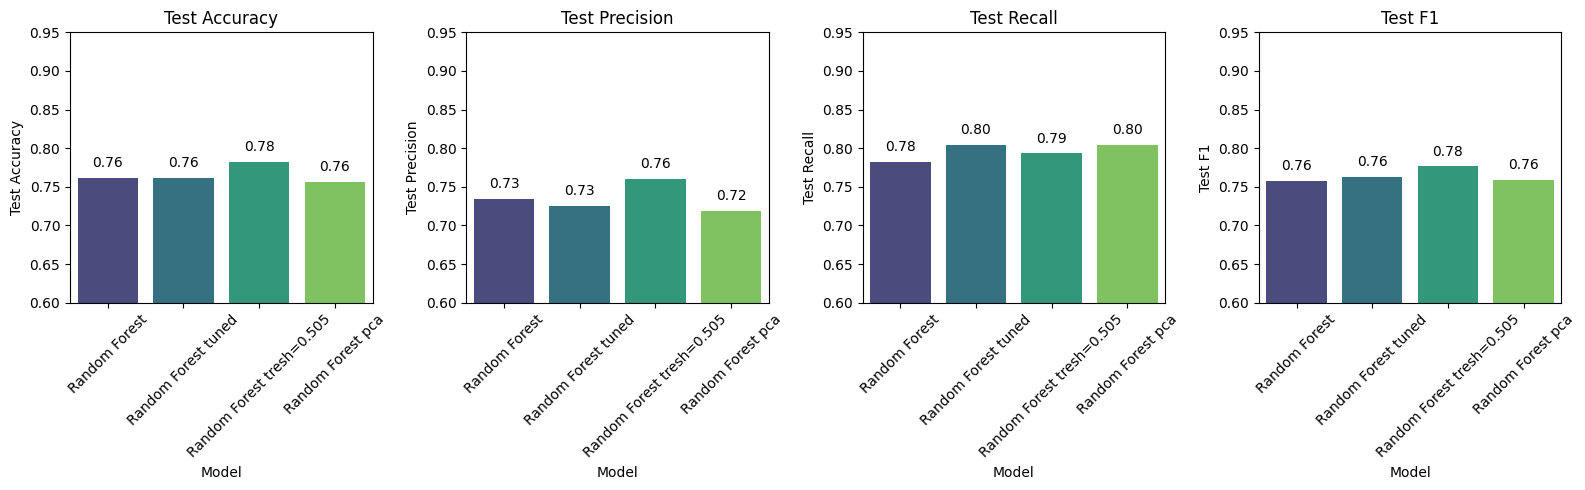

In [36]:
results_df = pd.DataFrame(results)
res_svm = results_df[results_df['Model'].isin(['Random Forest', 'Random Forest tuned', 'Random Forest tresh=0.505', 'Random Forest pca'])]

plt.figure(figsize=(16, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    ax = sns.barplot(x='Model', y=f'Test {metric}', data=res_svm, palette="viridis", hue='Model', legend=False)
    plt.title(f'Test {metric}')
    plt.ylim(0.6, 0.95)
    plt.xticks(rotation=45)

    # Добавление подписей значений
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()